# Are Flat Minima an Illusion? — Experiment v8

**Setup:** Runtime → Change runtime type → A100 GPU, High RAM → Save

Then click **Runtime → Run all**. Come back in ~1 hour.

**Design:** 3-layer MLP, 6K child task, 64K unseen region.
All networks train to 100% on the child task (500 epochs max, early stop).
Sharp regime uses lr=0.5 to compensate for few gradient steps per epoch.

In [ ]:
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    props = torch.cuda.get_device_properties(0)
    mem = getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)
    print(f'Memory: {mem/1e9:.1f} GB')
else:
    raise RuntimeError('No GPU. Go to Runtime > Change runtime type > GPU')

PyTorch: 2.10.0+cu128
CUDA: True
GPU: NVIDIA A100-SXM4-40GB
Memory: 42.4 GB


In [ ]:
######################################################################
# CONFIG
######################################################################
FAST_MODE = False  # True = ~10 min sanity check, False = full run

if FAST_MODE:
    N_PER_REGIME = 10
    TRAIN_EPOCHS = 200
    HESS_SAMPLES = 15
    BETAS = [1.0, 5.0, 10.0]
    TEST_NETS = [0, 10]  # one flat, one sharp
else:
    N_PER_REGIME = 25
    TRAIN_EPOCHS = 500
    HESS_SAMPLES = 50
    BETAS = [1.0, 2.0, 5.0, 10.0, 20.0]
    TEST_NETS = [0, 5, 25, 30]  # 2 flat, 2 sharp

D1, D2 = 256, 128  # hidden layer sizes
LR_FLAT, BS_FLAT = 0.01, 64
LR_SHARP, BS_SHARP = 0.5, 4096

N_TOTAL = 2 * N_PER_REGIME
print(f'Mode: {"FAST" if FAST_MODE else "FULL"}')
print(f'Networks: {N_PER_REGIME} flat + {N_PER_REGIME} sharp')
print(f'Architecture: 784 → {D1} → {D2} → 10')
print(f'Training epochs: {TRAIN_EPOCHS}')

Mode: FULL
Networks: 25 flat + 25 sharp
Architecture: 784 → 256 → 128 → 10
Training epochs: 500


In [ ]:
######################################################################
# DATA
######################################################################
from torchvision import datasets, transforms
import torch.nn as nn, torch.optim as optim
import numpy as np, time, json, copy
from scipy.stats import spearmanr

DEVICE = torch.device('cuda')
torch.manual_seed(42); np.random.seed(42)

transform = transforms.Compose([transforms.ToTensor(),
                                 transforms.Normalize((0.1307,),(0.3081,))])
train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('./data', train=False, download=True, transform=transform)

X_train_full = train_ds.data.float().view(-1,784).to(DEVICE)/255.0
y_train_full = train_ds.targets.to(DEVICE)
X_test = test_ds.data.float().view(-1,784).to(DEVICE)/255.0
y_test = test_ds.targets.to(DEVICE)

# Narrow child task: 6K training points (10% of MNIST)
# Smaller child task = larger unseen region = more room for weakness to vary
N_CHILD = 6000
child_idx = torch.randperm(len(X_train_full),
                           generator=torch.Generator().manual_seed(42))[:N_CHILD]
X_train = X_train_full[child_idx]
y_train = y_train_full[child_idx]

# Unseen region: everything NOT in the child task
# This is the remaining 54K training points + 10K test points = 64K
X_pool = torch.cat([X_train_full, X_test])
y_pool = torch.cat([y_train_full, y_test])
unseen_mask = torch.ones(len(X_pool), dtype=torch.bool, device=DEVICE)
unseen_mask[child_idx] = False
X_unseen = X_pool[unseen_mask]
y_unseen = y_pool[unseen_mask]

print(f'Child task: {len(X_train)} training points')
print(f'Unseen region: {len(X_unseen)} points')
print(f'Standard test set: {len(X_test)} points (subset of unseen)')


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.35MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 123kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.20MB/s]


Child task: 6000 training points
Unseen region: 64000 points
Standard test set: 10000 points (subset of unseen)


In [ ]:
######################################################################
# MODEL + UTILITIES
######################################################################
class MLP3(nn.Module):
    def __init__(self, d1=256, d2=128):
        super().__init__()
        self.fc1 = nn.Linear(784, d1)
        self.fc2 = nn.Linear(d1, d2)
        self.fc3 = nn.Linear(d2, 10)
    def forward(self, x):
        return self.fc3(torch.relu(self.fc2(torch.relu(self.fc1(x)))))

def train_model(epochs, batch_size, lr, seed):
    torch.manual_seed(seed)
    model = MLP3(D1, D2).to(DEVICE)
    opt = optim.SGD(model.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    N = len(X_train)
    for ep in range(epochs):
        perm = torch.randperm(N, device=DEVICE)
        for s in range(0, N, batch_size):
            idx = perm[s:s+batch_size]
            loss = loss_fn(model(X_train[idx]), y_train[idx])
            opt.zero_grad(); loss.backward(); opt.step()
        # Early stop check every 10 epochs
        if (ep+1) % 10 == 0:
            with torch.no_grad():
                ta = (model(X_train[:10000]).argmax(1)==y_train[:10000]).float().mean().item()
            if ta >= 0.9999:
                break
    return model

@torch.no_grad()
def accuracy(model, X, y, bs=4096):
    model.eval()
    c = sum((model(X[s:s+bs]).argmax(1)==y[s:s+bs]).sum().item()
            for s in range(0,len(X),bs))
    model.train()
    return c/len(X)

@torch.no_grad()
def get_preds(model, X, bs=4096):
    model.eval()
    p = torch.cat([model(X[s:s+bs]).argmax(1) for s in range(0,len(X),bs)])
    model.train()
    return p

def apply_T_beta(model, beta):
    """Scale between layers 1 and 2."""
    m = copy.deepcopy(model)
    with torch.no_grad():
        m.fc1.weight.mul_(beta); m.fc1.bias.mul_(beta)
        m.fc2.weight.mul_(1.0/beta)
    return m

def apply_T_gamma(model, gamma):
    """Scale between layers 2 and 3."""
    m = copy.deepcopy(model)
    with torch.no_grad():
        m.fc2.weight.mul_(gamma); m.fc2.bias.mul_(gamma)
        m.fc3.weight.mul_(1.0/gamma)
    return m

def hessian_trace(model, X, y, n_samples=50, bs=2048):
    loss_fn = nn.CrossEntropyLoss(); model.eval()
    if len(X)>bs:
        idx=torch.randperm(len(X))[:bs]; Xs,ys=X[idx],y[idx]
    else: Xs,ys=X,y
    traces=[]
    for _ in range(n_samples):
        model.zero_grad()
        grads=torch.autograd.grad(loss_fn(model(Xs),ys),
                                   model.parameters(),create_graph=True)
        vs=[torch.randint(0,2,p.shape,device=DEVICE).float()*2-1
            for p in model.parameters()]
        gv=sum((g*v).sum() for g,v in zip(grads,vs))
        hvps=torch.autograd.grad(gv, model.parameters())
        traces.append(sum((v*hv).sum().item() for v,hv in zip(vs,hvps)))
    model.train()
    return np.mean(traces)

@torch.no_grad()
def activation_patterns(model, X, bs=4096):
    """Count distinct binary activation patterns at each layer."""
    model.eval()
    all_pat1 = []
    all_pat2 = []
    for s in range(0, len(X), bs):
        Xb = X[s:s+bs]
        h1 = model.fc1(Xb)
        h2 = model.fc2(torch.relu(h1))
        # Pack bits into bytes for fast hashing
        all_pat1.append((h1 > 0).cpu().numpy())
        all_pat2.append((h2 > 0).cpu().numpy())
    pat1 = np.concatenate(all_pat1)
    pat2 = np.concatenate(all_pat2)
    # Count unique patterns using byte-view hashing
    u1 = len(set(pat1.tobytes()[i*pat1.shape[1]:(i+1)*pat1.shape[1]]
                 for i in range(len(pat1))))
    u2 = len(set(pat2.tobytes()[i*pat2.shape[1]:(i+1)*pat2.shape[1]]
                 for i in range(len(pat2))))
    model.train()
    return u1, u2

def ensemble_agreement(all_preds, y_true, idx):
    """
    For network idx, among points it gets wrong,
    what fraction do other networks get right?
    """
    pred_i = all_preds[idx]
    wrong = (pred_i != y_true)
    n_wrong = wrong.sum().item()
    if n_wrong == 0:
        return 1.0
    wrong_idx = torch.where(wrong)[0]
    n_others = len(all_preds) - 1
    other_correct = torch.zeros(n_wrong, device=y_true.device)
    for j, pj in enumerate(all_preds):
        if j == idx: continue
        other_correct += (pj[wrong_idx] == y_true[wrong_idx]).float()
    return (other_correct / n_others).mean().item()

print('Model utilities defined.')

Model utilities defined.


In [ ]:
######################################################################
# PHASE 1: TRAIN ALL NETWORKS TO 100% TRAINING ACCURACY
######################################################################
t_global = time.time()

configs = []
for s in range(N_PER_REGIME):
    configs.append(dict(batch_size=BS_FLAT, lr=LR_FLAT,
                        seed=s, label='flat'))
for s in range(N_PER_REGIME):
    configs.append(dict(batch_size=BS_SHARP, lr=LR_SHARP,
                        seed=s+100, label='sharp'))

networks = []
print('--- Phase 1: Training networks to 100% train acc ---')
for i, cfg in enumerate(configs):
    t0 = time.time()
    model = train_model(TRAIN_EPOCHS, cfg['batch_size'], cfg['lr'], cfg['seed'])
    tr = accuracy(model, X_train, y_train)
    te = accuracy(model, X_test, y_test)
    dt = time.time()-t0
    status = 'OK' if tr > 0.9999 else f'WARN train={tr:.4f}'
    print(f'  [{i+1:2d}/{N_TOTAL}] {cfg["label"]:5s} bs={cfg["batch_size"]:>4d} '
          f'train={tr:.4f} test={te:.4f} ({dt:.0f}s) {status}')
    networks.append(dict(model=model, config=cfg,
                         train_acc=tr, test_acc=te))

--- Phase 1: Training networks to 100% train acc ---
  [ 1/50] flat  bs=  64 train=1.0000 test=0.9392 (30s) OK
  [ 2/50] flat  bs=  64 train=1.0000 test=0.9390 (31s) OK
  [ 3/50] flat  bs=  64 train=1.0000 test=0.9405 (31s) OK
  [ 4/50] flat  bs=  64 train=1.0000 test=0.9410 (32s) OK
  [ 5/50] flat  bs=  64 train=1.0000 test=0.9410 (32s) OK
  [ 6/50] flat  bs=  64 train=1.0000 test=0.9374 (31s) OK
  [ 7/50] flat  bs=  64 train=1.0000 test=0.9408 (31s) OK
  [ 8/50] flat  bs=  64 train=1.0000 test=0.9379 (31s) OK
  [ 9/50] flat  bs=  64 train=1.0000 test=0.9389 (32s) OK
  [10/50] flat  bs=  64 train=1.0000 test=0.9377 (29s) OK
  [11/50] flat  bs=  64 train=1.0000 test=0.9394 (35s) OK
  [12/50] flat  bs=  64 train=1.0000 test=0.9434 (31s) OK
  [13/50] flat  bs=  64 train=1.0000 test=0.9388 (34s) OK
  [14/50] flat  bs=  64 train=1.0000 test=0.9399 (33s) OK
  [15/50] flat  bs=  64 train=1.0000 test=0.9395 (30s) OK
  [16/50] flat  bs=  64 train=1.0000 test=0.9390 (29s) OK
  [17/50] flat  bs=

In [ ]:
######################################################################
# CHECK: all networks at 100% train accuracy
######################################################################
all_memorised = all(n['train_acc'] > 0.9999 for n in networks)
print(f'All networks memorised training set: {all_memorised}')
if not all_memorised:
    for i, n in enumerate(networks):
        if n['train_acc'] <= 0.9999:
            print(f'  WARNING: Net {i} ({n["config"]["label"]}) '
                  f'train_acc={n["train_acc"]:.6f}')
    print('Consider increasing TRAIN_EPOCHS.')

# Summary
for regime in ['flat','sharp']:
    ns = [n for n in networks if n['config']['label']==regime]
    tes = [n['test_acc'] for n in ns]
    print(f'{regime.upper():6s}: test={np.mean(tes):.4f} '
          f'± {np.std(tes):.4f} '
          f'(min={np.min(tes):.4f}, max={np.max(tes):.4f})')

All networks memorised training set: True
FLAT  : test=0.9396 ± 0.0013 (min=0.9374, max=0.9434)
SHARP : test=0.9494 ± 0.0011 (min=0.9474, max=0.9513)


In [ ]:
######################################################################
# PHASE 2: COMPUTE ALL MEASURES
######################################################################
print('--- Phase 2: Computing measures ---')

# Collect test predictions for ensemble agreement
all_test_preds = []
for net in networks:
    all_test_preds.append(get_preds(net['model'], X_unseen))

for i, net in enumerate(networks):
    t0 = time.time()

    # Hessian trace
    ht = hessian_trace(net['model'], X_train, y_train,
                       n_samples=HESS_SAMPLES)
    net['hessian_trace'] = ht

    # Activation patterns
    u1, u2 = activation_patterns(net['model'], X_unseen)
    net['act_patterns_L1'] = u1
    net['act_patterns_L2'] = u2

    # Ensemble agreement
    ea = ensemble_agreement(all_test_preds, y_unseen, i)
    net['ensemble_agreement'] = ea

    # Error count
    n_wrong = (all_test_preds[i] != y_unseen).sum().item()
    net['n_wrong_test'] = n_wrong

    dt = time.time()-t0
    print(f'  [{i+1:2d}/{N_TOTAL}] {net["config"]["label"]:5s} '
          f'test={net["test_acc"]:.4f} hess={ht:8.2f} '
          f'L1={u1:5d} L2={u2:5d} EA={ea:.4f} ({dt:.1f}s)')

--- Phase 2: Computing measures ---
  [ 1/50] flat  test=0.9392 hess=   67.75 L1=63998 L2=51348 EA=0.1909 (272.9s)
  [ 2/50] flat  test=0.9390 hess=   65.57 L1=64000 L2=53895 EA=0.1909 (273.9s)
  [ 3/50] flat  test=0.9405 hess=   63.03 L1=63995 L2=53662 EA=0.1895 (275.8s)
  [ 4/50] flat  test=0.9410 hess=   63.17 L1=63998 L2=50217 EA=0.1834 (278.8s)
  [ 5/50] flat  test=0.9410 hess=   50.01 L1=63998 L2=54187 EA=0.1825 (281.1s)
  [ 6/50] flat  test=0.9374 hess=   66.22 L1=63992 L2=53799 EA=0.2018 (273.0s)
  [ 7/50] flat  test=0.9408 hess=   70.06 L1=64000 L2=54566 EA=0.1826 (277.9s)
  [ 8/50] flat  test=0.9379 hess=   66.65 L1=63994 L2=56768 EA=0.2004 (274.9s)
  [ 9/50] flat  test=0.9389 hess=   52.53 L1=64000 L2=55988 EA=0.1934 (273.3s)
  [10/50] flat  test=0.9377 hess=   71.29 L1=63996 L2=57945 EA=0.1990 (274.9s)
  [11/50] flat  test=0.9394 hess=   52.86 L1=63999 L2=56767 EA=0.1861 (272.1s)
  [12/50] flat  test=0.9434 hess=   62.87 L1=63997 L2=56112 EA=0.1735 (271.2s)
  [13/50] flat  

In [ ]:
######################################################################
# PHASE 3: REPARAMETERISATION INVARIANCE TEST
######################################################################
print('--- Phase 3: Reparameterisation invariance ---')
reparam = []

for ni in TEST_NETS:
    if ni >= len(networks):
        print(f'  Skipping net {ni} (only {len(networks)} networks)')
        continue
    net = networks[ni]
    lab = net['config']['label']
    print(f'\n  Net {ni} ({lab}, test={net["test_acc"]:.4f}):')

    for beta in BETAS:
        t0 = time.time()
        mb = apply_T_beta(net['model'], beta)

        te = accuracy(mb, X_test, y_test)
        ht = hessian_trace(mb, X_train, y_train, n_samples=HESS_SAMPLES)
        u1, u2 = activation_patterns(mb, X_unseen)

        # Ensemble agreement for the reparameterised net
        # Replace this net's predictions in the ensemble
        rp = get_preds(mb, X_unseen)
        tmp = all_test_preds[ni]
        all_test_preds[ni] = rp
        ea = ensemble_agreement(all_test_preds, y_unseen, ni)
        all_test_preds[ni] = tmp  # restore

        dt = time.time()-t0
        print(f'    T_beta={beta:5.1f}: test={te:.4f} hess={ht:10.2f} '
              f'L1={u1:5d} L2={u2:5d} EA={ea:.4f} ({dt:.1f}s)')
        reparam.append(dict(net=ni, label=lab, reparam='T_beta',
                            value=beta, test_acc=te, hessian_trace=ht,
                            act_L1=u1, act_L2=u2, ensemble_agr=ea))
        del mb; torch.cuda.empty_cache()

    # Also test T_gamma (between layers 2 and 3)
    for gamma in [1.0, 5.0, 20.0]:
        t0 = time.time()
        mg = apply_T_gamma(net['model'], gamma)

        te = accuracy(mg, X_test, y_test)
        ht = hessian_trace(mg, X_train, y_train, n_samples=HESS_SAMPLES)
        u1, u2 = activation_patterns(mg, X_unseen)

        rp = get_preds(mg, X_unseen)
        tmp = all_test_preds[ni]
        all_test_preds[ni] = rp
        ea = ensemble_agreement(all_test_preds, y_unseen, ni)
        all_test_preds[ni] = tmp

        dt = time.time()-t0
        print(f'    T_gamma={gamma:4.1f}: test={te:.4f} hess={ht:10.2f} '
              f'L1={u1:5d} L2={u2:5d} EA={ea:.4f} ({dt:.1f}s)')
        reparam.append(dict(net=ni, label=lab, reparam='T_gamma',
                            value=gamma, test_acc=te, hessian_trace=ht,
                            act_L1=u1, act_L2=u2, ensemble_agr=ea))
        del mg; torch.cuda.empty_cache()

--- Phase 3: Reparameterisation invariance ---

  Net 0 (flat, test=0.9392):
    T_beta=  1.0: test=0.9392 hess=     66.14 L1=63998 L2=51348 EA=0.1909 (272.1s)
    T_beta=  2.0: test=0.9392 hess=     81.29 L1=63998 L2=51348 EA=0.1909 (274.5s)
    T_beta=  5.0: test=0.9392 hess=    388.79 L1=63998 L2=51348 EA=0.1909 (274.8s)
    T_beta= 10.0: test=0.9392 hess=   1607.14 L1=63998 L2=51348 EA=0.1909 (274.9s)
    T_beta= 20.0: test=0.9392 hess=   6525.87 L1=63998 L2=51348 EA=0.1909 (272.3s)
    T_gamma= 1.0: test=0.9392 hess=     62.95 L1=63998 L2=51348 EA=0.1909 (271.6s)
    T_gamma= 5.0: test=0.9392 hess=    255.16 L1=63998 L2=51348 EA=0.1909 (271.6s)
    T_gamma=20.0: test=0.9392 hess=   3378.89 L1=63998 L2=51348 EA=0.1909 (274.4s)

  Net 5 (flat, test=0.9374):
    T_beta=  1.0: test=0.9374 hess=     54.67 L1=63992 L2=53799 EA=0.2018 (273.7s)
    T_beta=  2.0: test=0.9374 hess=     67.15 L1=63992 L2=53799 EA=0.2018 (274.6s)
    T_beta=  5.0: test=0.9374 hess=    370.86 L1=63992 L2=53799

In [ ]:
######################################################################
# CORRELATIONS
######################################################################
print('='*70)
print('  CORRELATIONS')
print('='*70)

ta = np.array([n['test_acc'] for n in networks])
ht = np.array([n['hessian_trace'] for n in networks])
u1 = np.array([n['act_patterns_L1'] for n in networks])
u2 = np.array([n['act_patterns_L2'] for n in networks])
ea = np.array([n['ensemble_agreement'] for n in networks])

measures = [
    ('Hessian trace', ht),
    ('L1 activation patterns', u1),
    ('L2 activation patterns', u2),
    ('Ensemble agreement', ea),
]

print(f'\nSpearman correlations with test accuracy (n={N_TOTAL}):')
print(f'{"Measure":>28s}   {"rho":>7s}   {"p-value":>10s}')
print('-'*52)
corr_results = {}
for name, vals in measures:
    if len(set(vals)) > 1:
        r, p = spearmanr(ta, vals)
        print(f'{name:>28s}   {r:+7.4f}   {p:10.6f}')
        corr_results[name] = {'r': float(r), 'p': float(p)}
    else:
        print(f'{name:>28s}   constant')

# Regime summaries
print(f'\n--- Regime summaries ---')
print(f'{"":>8s} {"test_acc":>9s} {"hessian":>9s} '
      f'{"L1_pat":>7s} {"L2_pat":>7s} {"EA":>7s}')
for regime in ['flat','sharp']:
    ns = [n for n in networks if n['config']['label']==regime]
    print(f'{regime.upper():>8s} '
          f'{np.mean([n["test_acc"] for n in ns]):9.4f} '
          f'{np.mean([n["hessian_trace"] for n in ns]):9.2f} '
          f'{np.mean([n["act_patterns_L1"] for n in ns]):7.0f} '
          f'{np.mean([n["act_patterns_L2"] for n in ns]):7.0f} '
          f'{np.mean([n["ensemble_agreement"] for n in ns]):7.4f}')

  CORRELATIONS

Spearman correlations with test accuracy (n=50):
                     Measure       rho      p-value
----------------------------------------------------
               Hessian trace   -0.7799     0.000000
      L1 activation patterns   +0.4046     0.003562
      L2 activation patterns   +0.7787     0.000000
          Ensemble agreement   -0.8578     0.000000

--- Regime summaries ---
          test_acc   hessian  L1_pat  L2_pat      EA
    FLAT    0.9396     61.88   63996   54569  0.1901
   SHARP    0.9494     25.92   63999   63194  0.1294


In [ ]:
######################################################################
# REPARAMETERISATION SUMMARY
######################################################################
print('='*70)
print('  REPARAMETERISATION SUMMARY')
print('='*70)

for ni in sorted(set(r['net'] for r in reparam)):
    rs = [r for r in reparam if r['net']==ni]
    lab = rs[0]['label']
    print(f'\nNet {ni} ({lab}):')
    print(f'  {"reparam":>10s} {"val":>5s} {"test":>8s} '
          f'{"hessian":>10s} {"L1":>6s} {"L2":>6s} {"EA":>7s}')

    for r in sorted(rs, key=lambda x: (x['reparam'], x['value'])):
        print(f'  {r["reparam"]:>10s} {r["value"]:5.1f} {r["test_acc"]:8.4f} '
              f'{r["hessian_trace"]:10.2f} {r["act_L1"]:6d} '
              f'{r["act_L2"]:6d} {r["ensemble_agr"]:7.4f}')

total_time = time.time() - t_global
print(f'\nTotal time: {total_time/60:.1f} minutes')

  REPARAMETERISATION SUMMARY

Net 0 (flat):
     reparam   val     test    hessian     L1     L2      EA
      T_beta   1.0   0.9392      66.14  63998  51348  0.1909
      T_beta   2.0   0.9392      81.29  63998  51348  0.1909
      T_beta   5.0   0.9392     388.79  63998  51348  0.1909
      T_beta  10.0   0.9392    1607.14  63998  51348  0.1909
      T_beta  20.0   0.9392    6525.87  63998  51348  0.1909
     T_gamma   1.0   0.9392      62.95  63998  51348  0.1909
     T_gamma   5.0   0.9392     255.16  63998  51348  0.1909
     T_gamma  20.0   0.9392    3378.89  63998  51348  0.1909

Net 5 (flat):
     reparam   val     test    hessian     L1     L2      EA
      T_beta   1.0   0.9374      54.67  63992  53799  0.2018
      T_beta   2.0   0.9374      67.15  63992  53799  0.2018
      T_beta   5.0   0.9374     370.86  63992  53799  0.2018
      T_beta  10.0   0.9374    1210.22  63992  53799  0.2018
      T_beta  20.0   0.9374    5921.38  63992  53799  0.2018
     T_gamma   1.0   0.937

In [ ]:
######################################################################
# SAVE JSON
######################################################################
class NpEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, (np.floating,)): return float(obj)
        if isinstance(obj, (np.integer,)): return int(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

save_nets = [{k:v for k,v in n.items() if k!='model'} for n in networks]
results = {'networks': save_nets, 'reparameterisation': reparam,
           'correlations': corr_results,
           'total_time_seconds': total_time}
with open('experiment_results_6000.json','w') as f:
    json.dump(results, f, indent=2, cls=NpEncoder)
print('Saved experiment_results_6000.json')

Saved experiment_results_v6.json


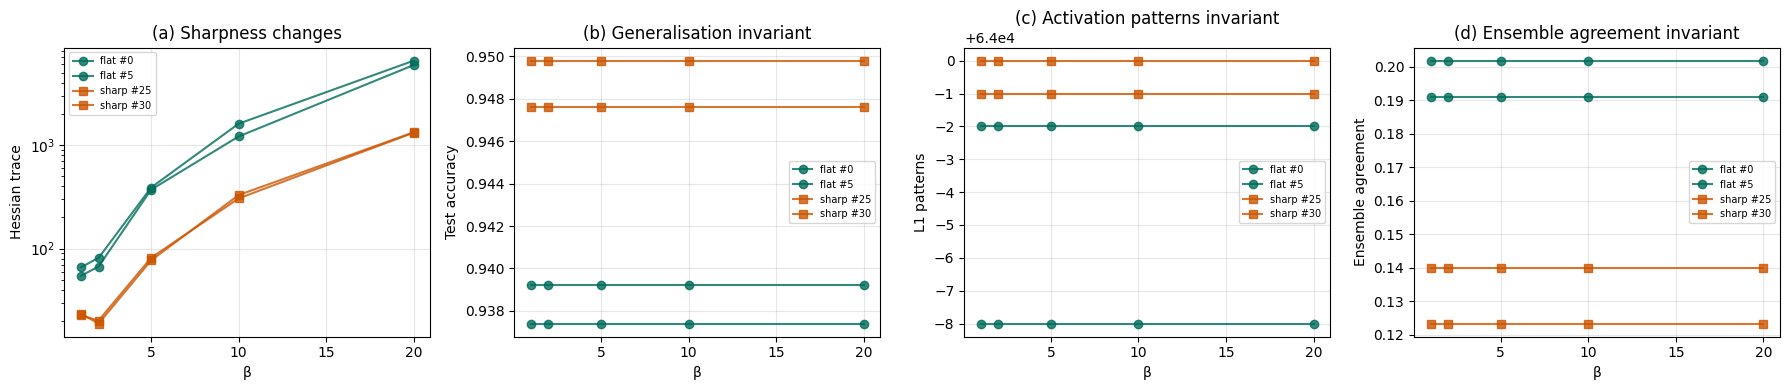

Saved fig1


In [ ]:
######################################################################
# FIGURE 1: REPARAMETERISATION INVARIANCE (T_beta only)
######################################################################
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Filter to T_beta only
rb = [r for r in reparam if r['reparam']=='T_beta']
net_ids = sorted(set(r['net'] for r in rb))
col = {'flat':'#006D5B','sharp':'#CC5500'}
mk = {'flat':'o','sharp':'s'}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ni in net_ids:
    rs = sorted([r for r in rb if r['net']==ni], key=lambda x:x['value'])
    lab = rs[0]['label']
    bs = [r['value'] for r in rs]
    axes[0].plot(bs,[r['hessian_trace'] for r in rs],
                f'{mk[lab]}-',color=col[lab],label=f'{lab} #{ni}',alpha=.8,ms=6)
    axes[1].plot(bs,[r['test_acc'] for r in rs],
                f'{mk[lab]}-',color=col[lab],label=f'{lab} #{ni}',alpha=.8,ms=6)
    axes[2].plot(bs,[r['act_L1'] for r in rs],
                f'{mk[lab]}-',color=col[lab],label=f'{lab} #{ni}',alpha=.8,ms=6)
    axes[3].plot(bs,[r['ensemble_agr'] for r in rs],
                f'{mk[lab]}-',color=col[lab],label=f'{lab} #{ni}',alpha=.8,ms=6)

axes[0].set(xlabel='β',ylabel='Hessian trace',title='(a) Sharpness changes')
axes[0].set_yscale('log')
axes[1].set(xlabel='β',ylabel='Test accuracy',title='(b) Generalisation invariant')
axes[2].set(xlabel='β',ylabel='L1 patterns',title='(c) Activation patterns invariant')
axes[3].set(xlabel='β',ylabel='Ensemble agreement',title='(d) Ensemble agreement invariant')
for ax in axes: ax.legend(fontsize=7); ax.grid(True,alpha=.3)
plt.tight_layout()
plt.savefig('fig1_reparam_6000.pdf',bbox_inches='tight',dpi=200)
plt.savefig('fig1_reparam_6000.png',bbox_inches='tight',dpi=200)
plt.show()
print('Saved fig1')

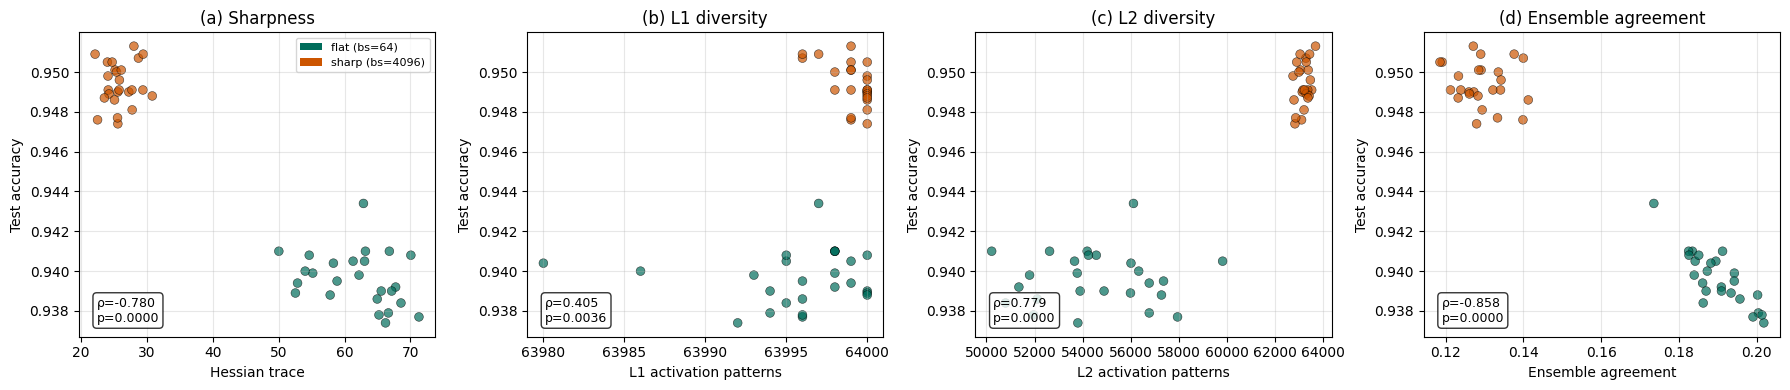

Saved fig2


In [ ]:
######################################################################
# FIGURE 2: CORRELATIONS WITH TEST ACCURACY
######################################################################
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
c_list = [col[n['config']['label']] for n in networks]

def scatter_corr(ax, x, y, c, xlabel, title):
    ax.scatter(x, y, c=c, s=40, alpha=.7, edgecolors='k', lw=.4)
    ax.set(xlabel=xlabel, ylabel='Test accuracy', title=title)
    if len(set(x))>1:
        r, p = spearmanr(y, x)
        ax.text(.05,.05,f'ρ={r:.3f}\np={p:.4f}',transform=ax.transAxes,
                fontsize=9,bbox=dict(boxstyle='round',fc='white',alpha=.8))
    ax.grid(True,alpha=.3)

scatter_corr(axes[0], ht, ta, c_list,
             'Hessian trace', '(a) Sharpness')
scatter_corr(axes[1], u1.astype(float), ta, c_list,
             'L1 activation patterns', '(b) L1 diversity')
scatter_corr(axes[2], u2.astype(float), ta, c_list,
             'L2 activation patterns', '(c) L2 diversity')
scatter_corr(axes[3], ea, ta, c_list,
             'Ensemble agreement', '(d) Ensemble agreement')

axes[0].legend(handles=[Patch(fc='#006D5B',label='flat (bs=64)'),
                        Patch(fc='#CC5500',label='sharp (bs=4096)')],fontsize=8)
plt.tight_layout()
plt.savefig('fig2_corr_6000.pdf',bbox_inches='tight',dpi=200)
plt.savefig('fig2_corr_6000.png',bbox_inches='tight',dpi=200)
plt.show()
print('Saved fig2')

In [ ]:
######################################################################
# DOWNLOAD
######################################################################
from google.colab import files
for f in ['experiment_results_6000.json',
          'fig1_reparam_6000.pdf','fig1_reparam_6000.png',
          'fig2_corr_6000.pdf','fig2_corr_6000.png']:
    try: files.download(f); print(f'Downloaded {f}')
    except Exception as e: print(f'Skip {f}: {e}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded experiment_results_v6.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded fig2_corr_v6.pdf


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded fig2_corr_v6.png
